## Lectue based on <a href="https://www.youtube.com/watch?v=TCH_1BHY58I">Makemore part2</a>

In [2]:
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## Glossary before start
### 🧠 Neural Network Architecture Glossary

#### 1. Data & Dimensions
* **Vocabulary Size (Vocab Size):** The total number of unique characters/tokens your model knows about. In Karpathy's text models, this is **27** (26 lowercase English letters + 1 special `.` token for the start/end of a word).
* **Context Window (Block Size / History Length):** The number of past tokens the model is allowed to look at to predict the very next one. For example, if the model looks at 3 characters to guess the 4th, the context window is **3**.
* **Batch Size:** The number of independent training examples packed together and fed into the computer *at the exact same time* so your hardware can process them in parallel. If `batch_size = 32`, you are crunching 32 independent character sequences simultaneously.
* **Embedding Dimension:** How many numbers you choose to describe *a single token* inside your embedding matrix. 
    * If your embedding matrix shape is `(27, 2)`, the embedding dimension is **2** (represented as coordinates on a 2D plane).
    * If your embedding matrix shape is `(27, 1)`, the embedding dimension is **1** (represented as points on a 1D number line).
* **Input Features:** The total amount of numbers representing a single training example when it actually reaches the first hidden layer. It is calculated mathematically as:
    $$\text{Input Features} = \text{Context Window} \times \text{Embedding Dimension}$$

---

#### 2. Neural Network Components
* **Embedding Matrix ($C$):** A lookup table of coordinates. Instead of feeding raw text characters to a computer, you look up their integer indices in this table to get a continuous vector of numbers that represents their "meaning."
* **Weights ($W$):** The adjustable parameters of the neural network. They are numbers that multiply incoming input data to scale its importance (e.g., *“care a lot about Input 1, ignore Input 2”*).
* **Biases ($b$):** An extra adjustable number added to each neuron *after* the weights multiply the inputs. It allows the neuron to shift its activation threshold left or right, independent of the inputs.
* **Neuron (Hidden Unit):** A single calculation node in a layer. It takes all incoming input features, multiplies them by its specific weights, adds its bias, and outputs a single number.
* **Hidden Dimension:** The number of neurons you choose to put inside a hidden layer (e.g., choosing **100** neurons for your first weight matrix `w1`).

---

#### 3. Shape Analysis (Putting It All Together)

When running a forward pass with a batch of data, your tensor shapes map directly to these concepts:

* **Input Data Matrix ($X$):** Shape is `(Batch Size, Input Features)`
    * *Example:* If `batch_size = 32`, `context_window = 3`, and `embedding_dim = 1`, the shape of $X$ entering the layer is **`(32, 3)`**.
* **Weight Matrix ($w1$):** Shape is `(Input Features, Hidden Dimension)`
    * *Example:* For 3 input features feeding into 100 hidden neurons, the shape is **`(3, 100)`**.

In [3]:
words = open('names.txt','r').read().splitlines()

FileNotFoundError: [Errno 2] No such file or directory: 'names.txt'

In [ ]:
len(words)

32033

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words :
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context) # here context is a list so getting shape of X as (16,3)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape

torch.Size([228146, 3])

In [ ]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
C = torch.randn((27,2))
C

tensor([[-0.4307, -1.6665],
        [-0.6566,  0.5907],
        [ 1.3929, -1.8084],
        [ 1.0175,  0.0104],
        [-0.5239,  0.2489],
        [ 0.3290,  1.0050],
        [ 0.0915,  0.9709],
        [ 0.6320, -2.9675],
        [ 0.4244, -1.2290],
        [ 0.4093, -0.2150],
        [-0.6387, -1.3968],
        [ 0.9604,  1.9717],
        [ 0.2040, -0.4249],
        [-1.1740,  1.6179],
        [-1.0134, -0.4848],
        [ 0.0414, -0.0849],
        [-1.9788, -0.2760],
        [ 0.4431,  2.9107],
        [-1.2700,  0.2617],
        [-0.2546, -2.4723],
        [-0.3886, -1.1157],
        [-0.4901, -0.2770],
        [-0.4995, -0.5493],
        [ 0.4542, -1.7780],
        [-0.1484, -0.3855],
        [-0.3748, -0.6442],
        [ 1.2549, -0.8546]])

## Theory check

This line is where the true neural network magic begins. Karpathy is building what is called an **Embedding Space** (specifically, a look-up table).

Computers don't understand characters, and they don't really like raw integers either because an integer implies an arbitrary scale (e.g., treating the letter 'z' at index 26 as "26 times bigger" than 'a' at index 1). Neural networks work best when data is represented as a list of continuous numbers—a **vector**.

Here is why that matrix is shaped exactly `(27, 2)`:

---

### Breaking Down the Dimensions: `(27, 2)`

#### The **27** (Rows)

You have exactly 27 unique characters in your vocabulary (the 26 letters of the English alphabet plus the special `.` token). This means **every single character gets its own dedicated row** in this matrix.

* Row 0 belongs to `.`
* Row 1 belongs to `a`
* Row 2 belongs to `b`, and so on.

#### The **2** (Columns)

This is the **embedding dimension**. Instead of representing a character with just a single rigid integer, Karpathy is giving *every single character* a pair of coordinates in a 2-dimensional space $(x, y)$.

In [ ]:
# What C looks like conceptually:
'''C = [
    [ 0.12, -1.45 ],  # Row 0: coordinates for '.'
    [-0.89,  0.34 ],  # Row 1: coordinates for 'a'
    [ 2.11, -0.11 ],  # Row 2: coordinates for 'b'
    ...
]'''

"C = [\n    [ 0.12, -1.45 ],  # Row 0: coordinates for '.'\n    [-0.89,  0.34 ],  # Row 1: coordinates for 'a'\n    [ 2.11, -0.11 ],  # Row 2: coordinates for 'b'\n    ...\n]"

---

### Why does he do this?

There are two major reasons why this is a foundational concept in deep learning:

#### 1. It lets the network learn similarity

Right now, `torch.randn` fills this matrix with completely random numbers. The characters are scattered randomly on a 2D plot.

However, because these numbers are parameters (`weights`), the neural network will adjust them during training. As the model learns which letters behave similarly, **it will physically move their coordinates closer together in this 2D space**.

* For example, vowels like `a`, `e`, `i`, `o`, `u` are often interchangeable in words. By the end of training, you will plot this matrix and see all the vowels clustered together in one corner, and consonants clustered in another!

#### 2. Why dimension 2?

Karpathy chooses **2** columns here purely so you can easily visualize it later in the video. Because it only has 2 columns, you can directly plug these coordinates into a simple 2D scatter plot (`plt.scatter`) and see exactly how the neural network groups the letters of the alphabet! In a production model (like GPT-4), this embedding dimension isn't 2—it might be 768, 1536, or even larger.

### How do you use it?

You can now use your `X` tensor as an index to "look up" coordinates from `C`. For instance, running `C[1]` will instantly grab the 2D vector assigned to the letter `'a'`.

### 1. The Conceptual Problem: The Number Line Trap

When you use a 1D embedding, every character gets assigned just a single number (e.g., $a = -1.2$, $e = 0.5$, $x = 2.3$). 

This forces the network to try and cram all the complex relationships of the English language onto a single line. 
* It might decide that vowels should be positive numbers and consonants should be negative numbers. 
* But what happens when it realizes that the letter `y` sometimes acts like a vowel and sometimes like a consonant? On a 1D number line, `y` can only be in *one* spot. It cannot be close to the vowels **and** close to the consonants at the same time.

By upgrading to 2D (or higher), you give the network an extra axis. Now, `y` can move "up" to be near vowels and "over" to be near consonants. More dimensions give the network the breathing room it needs to cluster data accurately.

---

### 2. The Shape Problem: Squeezing your Tensors

Let's look at how this affects the shapes of your tensors. If you use `C = torch.randn((27, 1))`, and you index into it using your `X` tensor (which has a shape of `(16, 3)`), PyTorch will look up a 1D vector for every single character.

Your resulting embedded tensor shape will become:
`torch.Size([16, 3, 1])`

#### Why that extra `, 1` at the end matters:
Later in the tutorial, Karpathy will want to concatenate or flatten the character embeddings of your context window so they can be fed into a linear layer ($W \cdot X + b$). 

If your shape is `[16, 3, 1]`, and you flatten those last two dimensions, your input to the neural network will only have **3 numbers total** per row (1 number for each of the 3 context characters). 
* With a 2D embedding, you have `[16, 3, 2]`, which flattens to **6 numbers total** per row. 

A neural network trying to predict the next character using only 3 numbers of input data has incredibly little information to work with, leading to much lower accuracy and a higher loss.

---

### Summary: Why not do it?
You *can* do it, but it acts like a bottleneck. 
* **1D:** Characters live on a line. Relationships are squished and oversimplified.
* **2D:** Characters live on a map. Vowels can cluster together, ending tokens can find their own corner, and punctuation can separate itself. 

In real-world LLMs, they use **thousands** of dimensions (e.g., 12,288 dimensions in GPT-4) because human language has thousands of overlapping semantic relationships that need to be mapped simultaneously!

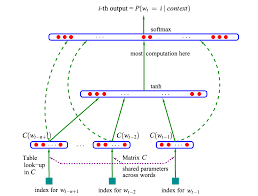
<a href="https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf">bengio03 paper</a>

## Back to work

In [ ]:
print(C[5]) #prints 6th row
print(C[[5,6,7]]) # prints 6,7,8th rows
#pytorch indexing is flexible 

tensor([0.3290, 1.0050])
tensor([[ 0.3290,  1.0050],
        [ 0.0915,  0.9709],
        [ 0.6320, -2.9675]])


In [ ]:
Z=np.ones((27,2))
Z[[1,2,3]]
#same works in numpy as well 🥵

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [ ]:
X.shape

torch.Size([228146, 3])

## Theory check

### Visualizing $C[X]$: The Filing Cabinet Analogy

To understand what $C[X]$ is doing, let's strip away the code and imagine a physical filing cabinet named **$C$**.

* This cabinet has **27 drawers** (numbered 0 to 26, one for each character in our vocabulary).
* Inside *every single drawer*, there are exactly **2 color-coded index cards** (representing our 2D coordinates, like `[0.5, -1.2]`).

---

### The Instructions Matrix ($X$)

Your $X$ tensor is just a sheet of paper containing a grid of instructions telling you which drawers to open. It has **16 rows** (training examples), and each row lists **3 drawer numbers** (our context length).

Let's look at just the very first row of your instructions:
$$X[0] = [0, 0, 0]$$

This is explicitly telling you: *"Go to drawer 0, then go to drawer 0, then go to drawer 0."*

---

### Walking through $C[X]$ Step-by-Step

When you run `C[X]`, PyTorch acts like a lightning-fast assistant executing those instructions simultaneously:

1. It looks at the first number in $X[0]$, which is `0`.
2. It runs over to the filing cabinet **$C$**, opens **drawer 0**, and pulls out the 2 numbers inside it (e.g., `[0.5, -1.2]`).
3. It places those 2 numbers into a new tray.
4. It repeats this for the second number (`0`) and the third number (`0`).

By the time it finishes just that *one* row, your single row of 3 integers `[0, 0, 0]` has been completely replaced by a row of 3 pairs of numbers:

$$\begin{bmatrix} [0.5, -1.2] & [0.5, -1.2] & [0.5, -1.2] \end{bmatrix}$$

---

### Zooming out to the 3D Shape: `[16, 3, 2]`

PyTorch performs this "search-and-replace" operation for all **16 rows** at the exact same time.

* **16 (Batch Size):** You still have exactly 16 training examples.
* **3 (Context Length):** Each example still contains a sequence of 3 characters.
* **2 (Embedding Dimension):** Each individual character has now been expanded into its 2D coordinate vector.

This transitions your data from a 2D grid of simple integers `(16, 3)` into a **3D space `(16, 3, 2)`**, giving the neural network the multi-dimensional feature representations it needs to calculate probabilities!

In [ ]:
'''import torch

# 1. Our Vocabulary Matrix (3 weather conditions: 0='sunny', 1='rainy', 2='cloudy')
# Embedding dimension = 2 (each weather state gets 2 coordinates)
weather_embeddings = torch.tensor([
    [ 2.5,  3.1],  # Row 0: Coordinates for 'sunny'
    [-1.8, -0.4],  # Row 1: Coordinates for 'rainy'
    [ 0.2,  1.7]   # Row 2: Coordinates for 'cloudy'
])

# 2. History Sequence Matrix (2 tracking cities, each checking a sequence of 3 days)
# Shape: (2, 3) -> 2 training examples, each with a history context of 3 days
history_indices = torch.tensor([
    [1, 2, 2],  # City A sequence: ['rainy', 'cloudy', 'cloudy']
    [0, 1, 0]   # City B sequence: ['sunny', 'rainy', 'sunny']
])

# 3. Look up the coordinates for all days across both cities
embedded_history = weather_embeddings[history_indices]

# 4. Print everything out to trace the mappings
print("=== Weather Embeddings Table ===")
print(weather_embeddings)
print("Shape:", weather_embeddings.shape)

print("\n=== History Indices Matrix ===")
print(history_indices)
print("Shape:", history_indices.shape)

print("\n=== Resulting 3D Embedded Tensor ===")
print(embedded_history)
print("Shape:", embedded_history.shape)'''

'import torch\n\n# 1. Our Vocabulary Matrix (3 weather conditions: 0=\'sunny\', 1=\'rainy\', 2=\'cloudy\')\n# Embedding dimension = 2 (each weather state gets 2 coordinates)\nweather_embeddings = torch.tensor([\n    [ 2.5,  3.1],  # Row 0: Coordinates for \'sunny\'\n    [-1.8, -0.4],  # Row 1: Coordinates for \'rainy\'\n    [ 0.2,  1.7]   # Row 2: Coordinates for \'cloudy\'\n])\n\n# 2. History Sequence Matrix (2 tracking cities, each checking a sequence of 3 days)\n# Shape: (2, 3) -> 2 training examples, each with a history context of 3 days\nhistory_indices = torch.tensor([\n    [1, 2, 2],  # City A sequence: [\'rainy\', \'cloudy\', \'cloudy\']\n    [0, 1, 0]   # City B sequence: [\'sunny\', \'rainy\', \'sunny\']\n])\n\n# 3. Look up the coordinates for all days across both cities\nembedded_history = weather_embeddings[history_indices]\n\n# 4. Print everything out to trace the mappings\nprint("=== Weather Embeddings Table ===")\nprint(weather_embeddings)\nprint("Shape:", weather_embedd

In [ ]:
weather_embeddings = torch.tensor([
    [ 2.5,  3.1],  # Row 0: Coordinates for 'sunny'
    [-1.8, -0.4],  # Row 1: Coordinates for 'rainy'
    [ 0.2,  1.7]   # Row 2: Coordinates for 'cloudy'
])

history_indices = torch.tensor([
    [1, 2, 2],  # City A sequence: ['rainy', 'cloudy', 'cloudy']
    [0, 1, 0]   # City B sequence: ['sunny', 'rainy', 'sunny']
])

In [ ]:
weather_embeddings.shape

torch.Size([3, 2])

In [ ]:
history_indices.shape

torch.Size([2, 3])

In [ ]:
embedded_history = weather_embeddings[history_indices]

In [ ]:
# dry run 
# first vector in the history_indices is [1,2,2]
# the output is something like [weather_embeddings[1],weather_embeddings[2],weather_embeddings[2]]
# the overall shape will be (1,3,2)(after first vector)
# the overall shape will be (2,3,2)(after all(two) vector)
print(embedded_history.size())
print(embedded_history[0])

torch.Size([2, 3, 2])
tensor([[-1.8000, -0.4000],
        [ 0.2000,  1.7000],
        [ 0.2000,  1.7000]])


In [ ]:
print(embedded_history[1])

tensor([[ 2.5000,  3.1000],
        [-1.8000, -0.4000],
        [ 2.5000,  3.1000]])


## Back to work

In [ ]:
C[X].shape

torch.Size([228146, 3, 2])

In [ ]:
X[13,2]

tensor(1)

In [ ]:
X.shape

torch.Size([228146, 3])

In [ ]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
w1=torch.randn((6,100))
b1=torch.randn(100)

## Theory

### 🔄 The Shift: Video 1 (Bigram) vs. Video 2 (MLP)

The reason the number **27** is showing up differently is because Karpathy completely changes how he feeds characters into the neural network between the first two videos.

---

#### 1. Video 1: The Bigram Model (One-Hot Encoding)
In the first video, there is **no embedding dimension**. Instead, he uses **One-Hot Encoding** to represent letters. Every character is converted into a list of 27 numbers where 26 are zeros and exactly one is a `1`.
*   *Example:* Letter `a` becomes `[1, 0, 0, 0, ... 0]` (length 27).
*   **The Weight Matrix ($W$):** `torch.randn((27, 27))`
*   **The Math:** It maps 27 inputs (the one-hot slots) directly to 27 outputs (the logits/probabilities for the next character). 

---

#### 2. Video 2: The MLP Model (Dense Embeddings)
In this video, he drops one-hot encoding because it treats all letters as completely unrelated. Instead, he introduces an **Embedding Matrix ($C$)** to give letters continuous numerical coordinates.
*   **The Matrix ($C$):** `torch.randn((27, 2))`
    *   **`27`:** The vocabulary size (number of rows in our lookup table).
    *   **`2`:** The **Embedding Dimension** (number of columns). Each character is now compressed into a 2-number coordinate space $(x, y)$. 
*   *Why 2?* Karpathy chose 2 because it allows him to plot the letters on a 2D graph at the end of the video, visually showing you how the network groups similar characters (like vowels) together.

---

### 📊 Summary Comparison

| Concept | Video 1 (Bigram Model) | Video 2 (MLP Model) |
| :--- | :--- | :--- |
| **Input Representation** | One-Hot Vector (sparse) | Embedding Vector (dense) |
| **Role of 27** | It is the **Input Size** of the layer | It is the **Vocab Size** (rows of table $C$) |
| **Embedding Dimension** | *None* | **2** (columns of table $C$) |
| **Context Window** | 1 character | **3** characters |
| **Total Input Features** | 27 inputs | 6 inputs ($3 \text{ chars} \times 2 \text{ dimensions}$) |
| **First Layer Weights** | `W = torch.randn((27, 27))` | `w1 = torch.randn((6, 100))` |

X is a tensor of shape(32,3) since block size is 3 the context size is also 3 <br>
* first thing to decide is what is the number of inputs (what the number of things in the input layer) <a href="https://media.geeksforgeeks.org/wp-content/uploads/20260504165306325617/Input-layer-in-ANN.webp">reference image</a>
Here the number of input features is bascically what we think is that the $batch size$ is $3$ but for a char we are giving $2$ Embedding dimensions so it's $3x2 = 6$

## Back to work
<a href="https://docs.pytorch.org/docs/2.12/generated/torch.cat.html">torch.cat()</a>

In [ ]:
#emb @ w1 + b dim soent match so no direct multiplication

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
emb[:,0,:]

tensor([[-0.4307, -1.6665],
        [-0.4307, -1.6665],
        [-0.4307, -1.6665],
        ...,
        [ 1.2549, -0.8546],
        [ 1.2549, -0.8546],
        [-0.3748, -0.6442]])

In [ ]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1) # method 1

tensor([[-0.4307, -1.6665, -0.4307, -1.6665, -0.4307, -1.6665],
        [-0.4307, -1.6665, -0.4307, -1.6665,  0.3290,  1.0050],
        [-0.4307, -1.6665,  0.3290,  1.0050, -1.1740,  1.6179],
        ...,
        [ 1.2549, -0.8546,  1.2549, -0.8546, -0.3748, -0.6442],
        [ 1.2549, -0.8546, -0.3748, -0.6442,  1.2549, -0.8546],
        [-0.3748, -0.6442,  1.2549, -0.8546, -0.1484, -0.3855]])

In [ ]:
C.shape

torch.Size([27, 2])

In [ ]:
print(C[0])

tensor([-0.4307, -1.6665])


In [ ]:
cat_emb = emb.view(-1, 6) # same as torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1)
cat_emb # actually here you will get a better understanding of why there should be 6 input features
# method 2(most efficent one!)

tensor([[-0.4307, -1.6665, -0.4307, -1.6665, -0.4307, -1.6665],
        [-0.4307, -1.6665, -0.4307, -1.6665,  0.3290,  1.0050],
        [-0.4307, -1.6665,  0.3290,  1.0050, -1.1740,  1.6179],
        ...,
        [ 1.2549, -0.8546,  1.2549, -0.8546, -0.3748, -0.6442],
        [ 1.2549, -0.8546, -0.3748, -0.6442,  1.2549, -0.8546],
        [-0.3748, -0.6442,  1.2549, -0.8546, -0.1484, -0.3855]])

In [ ]:
torch.cat(torch.unbind(emb,1),1).shape #this is also same 
# method 3

torch.Size([228146, 6])

In [ ]:
# prefer method2,3 not 1 but learn 1!

In [ ]:
# emb.view(32,6) @ w1 + b1
print(emb.shape[0])
# automatic implementation rather than hardcoding
#print(emb.view(emb.shape[0],6) @ w1 + b1)
print(emb.view(-1,6) @ w1 + b1) # -1 auto adjust to shape

228146
tensor([[-5.1189, -4.2411, -0.0648,  ..., -1.2702,  1.9513, -3.2493],
        [-3.9976,  0.7604,  3.3667,  ...,  2.6333,  2.6914,  0.5066],
        [ 2.1320, -0.1178,  0.7723,  ...,  2.6855, -3.5943,  3.3089],
        ...,
        [ 0.5977, -2.3434,  3.3615,  ..., -3.3114,  0.5377,  2.8436],
        [-2.2397, -1.0594, -1.4172,  ..., -1.9449,  1.8278, -1.0978],
        [-2.3027, -2.0004,  2.2448,  ..., -2.0722, -0.5589,  0.8978]])


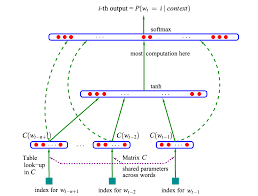

In [ ]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1) #the hidden layer
h

tensor([[-0.9999, -0.9996, -0.0647,  ..., -0.8539,  0.9604, -0.9970],
        [-0.9993,  0.6413,  0.9976,  ...,  0.9897,  0.9909,  0.4673],
        [ 0.9723, -0.1172,  0.6483,  ...,  0.9907, -0.9985,  0.9973],
        ...,
        [ 0.5354, -0.9817,  0.9976,  ..., -0.9973,  0.4913,  0.9932],
        [-0.9776, -0.7854, -0.8890,  ..., -0.9599,  0.9496, -0.7997],
        [-0.9802, -0.9641,  0.9778,  ..., -0.9688, -0.5071,  0.7152]])

In [ ]:
h.shape #100 is the number of neurons 

In [ ]:
# the next hidden layer
w2 = torch.randn((100,27))
b2 = torch.randn(27)

In [ ]:
logits = h @ w2 + b2

In [ ]:
logits.shape

torch.Size([228146, 27])

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts /counts.sum(1,keepdims=True)

In [ ]:
prob[0].sum()

tensor(1.)

In [ ]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
Y.shape

torch.Size([228146])

In [ ]:
# now go to each row and get the prob of correct Y with these weights and bias
prob[torch.arange(32),Y].shape

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
loss = -prob[torch.arange(32),Y].log().mean()

In [ ]:
loss

# ------------ now made respectable :) ---------------

In [ ]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(32,6) @ W1 + b1) #the hidden layer
logits = h @ W2 + b2
counts = logits.exp()
prob = counts/counts.sum(1,keepdims=True)
loss = -prob[torch.arange(32),Y].log().mean()
loss

In [ ]:
F.cross_entropy(logits,Y)

In [ ]:
emb = C[X]
h = torch.tanh(emb.view(32,6) @ w1 + b1) #the hidden layer
logits = h @ w2 + b2
#counts = logits.exp()
#prob = counts/counts.sum(1,keepdims=True)
#loss = -prob[torch.arange(32),Y].log().mean()
loss = F.cross_entropy(logits,Y)
loss

In [ ]:
# forward pass
for _ in range(100):
    # mini batch
    ix = torch.randint(0,X.shape[0],(32,))
    for p in parameters:
        p.requires_grad = True
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #the hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    #print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update 
    for p in parameters:
        p.data += -0.1*p.grad
print(loss.item())

In [ ]:
# actual loss
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #the hidden layer
logits = h @ W2 + b2
#counts = logits.exp()
#prob = counts/counts.sum(1,keepdims=True)
#loss = -prob[torch.arange(32),Y].log().mean()
loss = F.cross_entropy(logits,Y)
loss

In [ ]:
logits.max(1).indices == Y

In [ ]:
Y

In [ ]:
torch.randint(0,X.shape[0],(32,)).shape

In [ ]:
emb.shape

## Judging the learning rate

In [ ]:
lre = torch.linspace(-3,0,1000) # learn rate exponent
lrs = 10**lre # list of learning rates

In [ ]:
for p in parameters:
    p.requires_grad = True

In [ ]:
lri = []
lossi = []
for i in range(100):
    
        # Forward Pass
    
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #the hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y)
    #print(loss.item())
    
    # backward pass
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update 
    
    for p in parameters:
        p.data += -lrs[i]*p.grad
        # track stats
    lossi.append(loss.item())
    lri.append(lrs[i])

In [ ]:
len(lri)

In [ ]:
# actually running this in google colab leads me to decide 0.1 is best learning rate

In [ ]:
# training split, dev/validation split,test split
# 80%,10%,10%